In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/telco_churn.csv")


In [3]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
print("\nColumn types:\n", df.dtypes)


Column types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("\nChurn distribution:\n", df['Churn'].value_counts())


Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [13]:
df[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)

In [20]:
df['TotalCharges']= df['TotalCharges'].astype(float)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Text(0.5, 0, 'Churn')

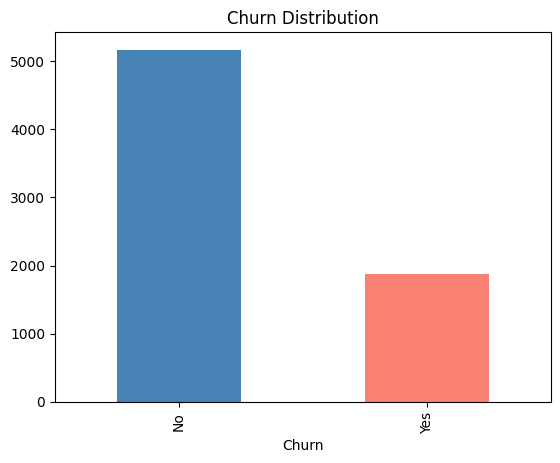

In [26]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')

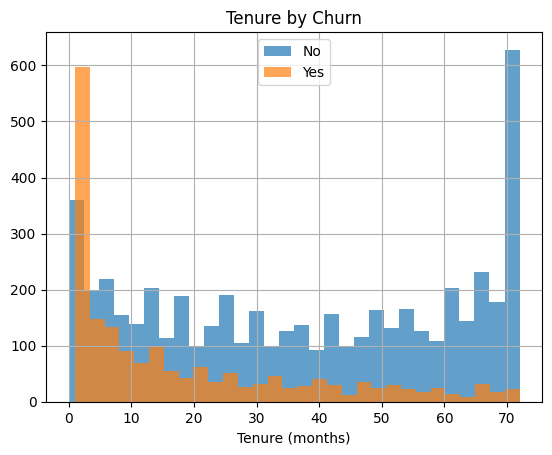

In [27]:
df.groupby('Churn')['tenure'].hist(alpha=0.7, bins=30)
plt.title('Tenure by Churn')
plt.xlabel('Tenure (months)')
plt.legend(['No', 'Yes'])

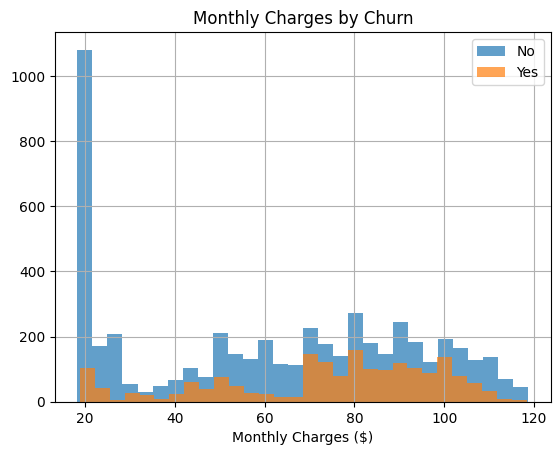

In [28]:
df.groupby('Churn')['MonthlyCharges'].hist(alpha=0.7, bins=30)
plt.title('Monthly Charges by Churn')
plt.xlabel('Monthly Charges ($)')
plt.legend(['No', 'Yes'])

In [29]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Check unique values for each
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic c

In [30]:
# Drop customerID - it's just an identifier, no predictive value
df = df.drop(columns=['customerID'])

In [31]:
# Convert target to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [32]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [33]:
# One-hot encode remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Columns to one-hot encode:", cat_cols)


Columns to one-hot encode: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [34]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", df.shape)
print("\nAll columns:\n", df.columns.tolist())


Shape after encoding: (7043, 31)

All columns:
 ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [35]:
# High charges relative to tenure = high risk signal
df['charges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

print("Sample of new feature:")
print(df[['tenure', 'TotalCharges', 'charges_per_tenure']].head())

Sample of new feature:
   tenure  TotalCharges  charges_per_tenure
0       1         29.85           14.925000
1      34       1889.50           53.985714
2       2        108.15           36.050000
3      45       1840.75           40.016304
4       2        151.65           50.550000


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y       # ← keeps the 73/27 ratio in both splits
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("\nChurn rate in train:", y_train.mean().round(3))
print("Churn rate in test: ", y_test.mean().round(3))

Training set: (5634, 31)
Test set:     (1409, 31)

Churn rate in train: 0.265
Churn rate in test:  0.265


In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# scale_pos_weight handles class imbalance
# ratio of negative to positive = 5174/1869 ≈ 2.77
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,   # ← tells model "churners are rare, pay attention"
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)
print("Training done!")

scale_pos_weight: 2.77
Training done!


ROC-AUC Score: 0.842

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



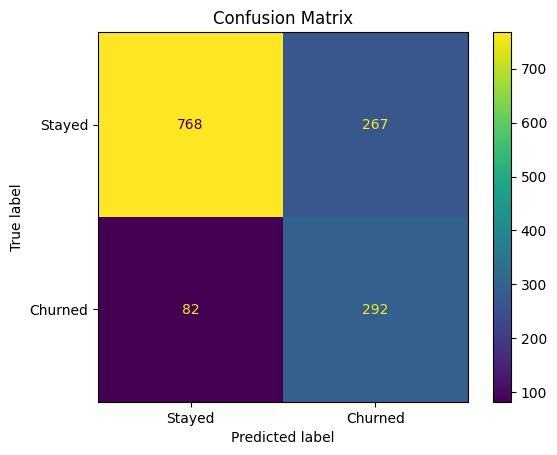

In [39]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob).round(4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Stayed', 'Churned'])
plt.title("Confusion Matrix")
plt.show()

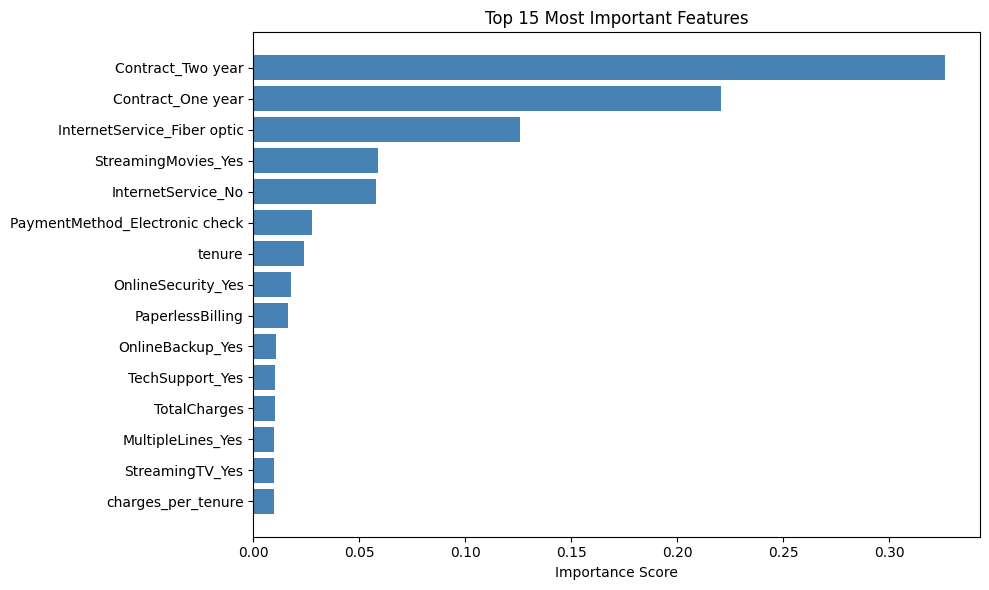

                           feature  importance
26               Contract_Two year    0.326400
25               Contract_One year    0.220629
11     InternetService_Fiber optic    0.126007
24             StreamingMovies_Yes    0.058988
12              InternetService_No    0.057914
28  PaymentMethod_Electronic check    0.027556
3                           tenure    0.023816
14              OnlineSecurity_Yes    0.017733
5                 PaperlessBilling    0.016361
16                OnlineBackup_Yes    0.010886
20                 TechSupport_Yes    0.010384
7                     TotalCharges    0.010249
10               MultipleLines_Yes    0.009804
22                 StreamingTV_Yes    0.009754
30              charges_per_tenure    0.009597


In [40]:

# Get feature importances
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][::-1], importance['importance'][::-1], color='steelblue')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance)

In [41]:
import os
import pickle

os.makedirs('../models', exist_ok=True)

with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save the feature columns - we'll need these later
import json
with open('../models/feature_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)

print("Model saved!")
print("Features saved!")

Model saved!
Features saved!
